# Import Library

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import style
style.use('dark_background')
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score, accuracy_score, ConfusionMatrixDisplay

In [2]:
pd.set_option('display.max_columns', None)

# Load Dataset

**Kolom pada dataset**

---
1. trans_date_trans_time: Waktu transaksi. Dapat digunakan untuk mendeteksi pola waktu (misal transaksi yang sering terjadi pada waktu yang tidak wajar bisa dicurigai sebagai fraud).
2. cc_num: Nomor kartu kredit. Informasi penting terkait pengguna kartu, tetapi tidak langsung membantu mendeteksi fraud kecuali ada pola dari penggunaan kartu yang tidak biasa.
3. merchant: Nama merchant (penjual). Merchant tertentu mungkin lebih sering terlibat dalam transaksi fraud, sehingga bisa membantu mendeteksi risiko terkait merchant.
4. category: Kategori transaksi. Fraud mungkin lebih sering terjadi dalam kategori tertentu seperti barang mewah atau hiburan, yang memiliki nilai transaksi lebih tinggi.
5. amt: Jumlah uang dalam transaksi. Nilai transaksi yang sangat besar atau tidak sesuai dengan pola belanja biasanya bisa menjadi tanda fraud.
6. first: Nama depan pemegang kartu. Tidak terlalu relevan dalam mendeteksi fraud secara langsung.
7. last: Nama belakang pemegang kartu. Sama seperti first, tidak relevan secara langsung.
8. gender: Jenis kelamin pemegang kartu. Bisa digunakan untuk melihat pola demografis terkait fraud, meskipun tidak secara langsung mengindikasikan fraud.
9. street: Alamat jalan pemegang kartu. Dapat digunakan dalam deteksi anomali jika lokasi transaksi berbeda jauh dari alamat pemegang kartu.
10. city: Kota pemegang kartu. Sama seperti street, dapat digunakan untuk memeriksa ketidaksesuaian antara lokasi pemegang kartu dan transaksi.
11. state: Negara bagian pemegang kartu. Sama dengan city, bisa mendeteksi anomali lokasi.
12. zip: Kode pos pemegang kartu. Sama dengan city dan state, bisa membantu mendeteksi anomali geografis.
13. lat: Garis lintang lokasi pemegang kartu. Lokasi geografis dapat membantu mendeteksi ketidaksesuaian jika dibandingkan dengan lokasi transaksi.
14. long: Garis bujur lokasi pemegang kartu. Sama dengan lat, membantu mendeteksi lokasi.
15. city_pop: Populasi kota pemegang kartu. Bisa digunakan untuk memahami risiko terkait daerah, misalnya daerah padat penduduk mungkin memiliki lebih banyak transaksi dan risiko.
16. job: Pekerjaan pemegang kartu. Pekerjaan dengan penghasilan tinggi mungkin lebih rentan terhadap fraud karena lebih sering terlibat dalam transaksi besar.
17. dob: Tanggal lahir pemegang kartu. Usia pemegang kartu bisa menjadi faktor, misalnya kelompok usia tertentu mungkin lebih rentan terhadap fraud.
18. trans_num: ID unik untuk transaksi. Tidak relevan dalam deteksi fraud secara langsung.
19. unix_time: Waktu transaksi dalam format unix. Sama seperti trans_date_trans_time, membantu dalam menganalisis pola waktu.
20. merch_lat: Garis lintang merchant. Dapat digunakan untuk mendeteksi ketidaksesuaian antara lokasi merchant dan pemegang kartu.
21. merch_long: Garis bujur merchant. Sama seperti merch_lat, membantu mendeteksi anomali lokasi.
22. is_fraud: Label apakah transaksi adalah fraud (0 = tidak fraud, 1 = fraud). Ini adalah target yang perlu diprediksi.


In [4]:
df_fraud = pd.read_csv('fraudTrain.csv')
df_fraud

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,28654,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,ID,83252,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,VA,24433,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1296670,1296670,2020-06-21 12:12:08,30263540414123,fraud_Reichel Inc,entertainment,15.56,Erik,Patterson,M,162 Jessica Row Apt. 072,Hatch,UT,84735,37.7175,-112.4777,258,Geoscientist,1961-11-24,440b587732da4dc1a6395aba5fb41669,1371816728,36.841266,-111.690765,0
1296671,1296671,2020-06-21 12:12:19,6011149206456997,fraud_Abernathy and Sons,food_dining,51.70,Jeffrey,White,M,8617 Holmes Terrace Suite 651,Tuscarora,MD,21790,39.2667,-77.5101,100,"Production assistant, television",1979-12-11,278000d2e0d2277d1de2f890067dcc0a,1371816739,38.906881,-78.246528,0
1296672,1296672,2020-06-21 12:12:32,3514865930894695,fraud_Stiedemann Ltd,food_dining,105.93,Christopher,Castaneda,M,1632 Cohen Drive Suite 639,High Rolls Mountain Park,NM,88325,32.9396,-105.8189,899,Naval architect,1967-08-30,483f52fe67fabef353d552c1e662974c,1371816752,33.619513,-105.130529,0
1296673,1296673,2020-06-21 12:13:36,2720012583106919,"fraud_Reinger, Weissnat and Strosin",food_dining,74.90,Joseph,Murray,M,42933 Ryan Underpass,Manderson,SD,57756,43.3526,-102.5411,1126,Volunteer coordinator,1980-08-18,d667cdcbadaaed3da3f4020e83591c83,1371816816,42.788940,-103.241160,0


In [5]:
train = pd.read_csv('fraudTrain.csv', index_col=0)
train.head()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,28654,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,ID,83252,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,VA,24433,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [6]:
train.columns

Index(['trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt',
       'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat',
       'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat',
       'merch_long', 'is_fraud'],
      dtype='object')

In [7]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1296675 entries, 0 to 1296674
Data columns (total 22 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   trans_date_trans_time  1296675 non-null  object 
 1   cc_num                 1296675 non-null  int64  
 2   merchant               1296675 non-null  object 
 3   category               1296675 non-null  object 
 4   amt                    1296675 non-null  float64
 5   first                  1296675 non-null  object 
 6   last                   1296675 non-null  object 
 7   gender                 1296675 non-null  object 
 8   street                 1296675 non-null  object 
 9   city                   1296675 non-null  object 
 10  state                  1296675 non-null  object 
 11  zip                    1296675 non-null  int64  
 12  lat                    1296675 non-null  float64
 13  long                   1296675 non-null  float64
 14  city_pop               

In [8]:
train.shape

(1296675, 22)

# EDA

In [9]:
train.describe()

,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06
mean,4.171920e+17,7.035104e+01,4.880067e+04,3.853762e+01,-9.022634e+01,8.882444e+04,1.349244e+09,3.853734e+01,-9.022646e+01,5.788652e-03
std,1.308806e+18,1.603160e+02,2.689322e+04,5.075808e+00,1.375908e+01,3.019564e+05,1.284128e+07,5.109788e+00,1.377109e+01,7.586269e-02
min,6.041621e+10,1.000000e+00,1.257000e+03,2.002710e+01,-1.656723e+02,2.300000e+01,1.325376e+09,1.902779e+01,-1.666712e+02,0.000000e+00
25%,1.800429e+14,9.650000e+00,2.623700e+04,3.462050e+01,-9.679800e+01,7.430000e+02,1.338751e+09,3.473357e+01,-9.689728e+01,0.000000e+00
50%,3.521417e+15,4.752000e+01,4.817400e+04,3.935430e+01,-8.747690e+01,2.456000e+03,1.349250e+09,3.936568e+01,-8.743839e+01,0.000000e+00
75%,4.642255e+15,8.314000e+01,7.204200e+04,4.194040e+01,-8.015800e+01,2.032800e+04,1.359385e+09,4.195716e+01,-8.023680e+01,0.000000e+00
max,4.992346e+18,2.894890e+04,9.978300e+04,6.669330e+01,-6.795030e+01,2.906700e+06,1.371817e+09,6.751027e+01,-6.695090e+01,1.000000e+00


In [10]:
train.columns

Index(['trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt',
       'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat',
       'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat',
       'merch_long', 'is_fraud'],
      dtype='object')

In [11]:
train.head(1)

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,28654,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0


## Data Type Categories

In [23]:
# Action Items : Drop Kolom
indetifer = ['cc_num', 'first', 'last', 'trans_num']

# Action Items : New Features, OHE , Label Encoder (bertingkat) Manually, Grouping into a bigger group OR nunique more than 20 then drop
category = ['merchant', 'category', 'gender', 'street', 'city', 'state', 'zip', 'job', 'unix_time']

# Action Items : New Features = Distance
location = ['lat', 'long', 'merch_lat', 'merch_long']

# Action Items : New Features = Risk Time, Risk Day, Age since user transaction
datetime = ['trans_date_trans_time', 'dob']

# Action Items : New Features : city_pop category, amt category : High, Medium, Low
numerical = ['amt', 'city_pop']

# Action Items : Target Variabel to Modelling
target = ['is_fraud']

In [24]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1296675 entries, 0 to 1296674
Data columns (total 22 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   trans_date_trans_time  1296675 non-null  object 
 1   cc_num                 1296675 non-null  int64  
 2   merchant               1296675 non-null  object 
 3   category               1296675 non-null  object 
 4   amt                    1296675 non-null  float64
 5   first                  1296675 non-null  object 
 6   last                   1296675 non-null  object 
 7   gender                 1296675 non-null  object 
 8   street                 1296675 non-null  object 
 9   city                   1296675 non-null  object 
 10  state                  1296675 non-null  object 
 11  zip                    1296675 non-null  int64  
 12  lat                    1296675 non-null  float64
 13  long                   1296675 non-null  float64
 14  city_pop               

In [25]:
# Melihat variasi data
for category in train[category].columns:
  print(f'Kolom {category} : {train[category].nunique()}')

Kolom merchant : 693
Kolom category : 14
Kolom gender : 2
Kolom street : 983
Kolom city : 894
Kolom state : 51
Kolom zip : 970
Kolom job : 494
Kolom unix_time : 1274823


In [26]:
# Filter data yang fraud
fraud = train.loc[train['is_fraud'] == 1].copy() # Use .copy() to avoid SettingWithCopyWarning
print(f'Data Fraud : {len(fraud)}')

# filter fraud berdasar tahun
# Ensure 'year' column exists or extract it from datetime column if needed
if 'year' not in fraud.columns:
    # Assuming 'trans_date_trans_time' is a datetime column
    fraud['year'] = pd.to_datetime(fraud['trans_date_trans_time']).dt.year

fraud_19 = fraud.loc[fraud['year'] == 2019]
fraud_20 = fraud.loc[fraud['year'] == 2020]

print(f'Data Fraud 2019 : {len(fraud_19)}')
print(f'Data Fraud 2020: {len(fraud_20)}')

Data Fraud : 7506
Data Fraud 2019 : 5220
Data Fraud 2020: 2286


## Fraud Category Distribution

In [28]:
train['is_fraud'].value_counts()

,count
is_fraud,
0,1289169
1,7506


In [29]:
train['is_fraud'].value_counts(normalize=True)

,proportion
is_fraud,
0,0.994211
1,0.005789


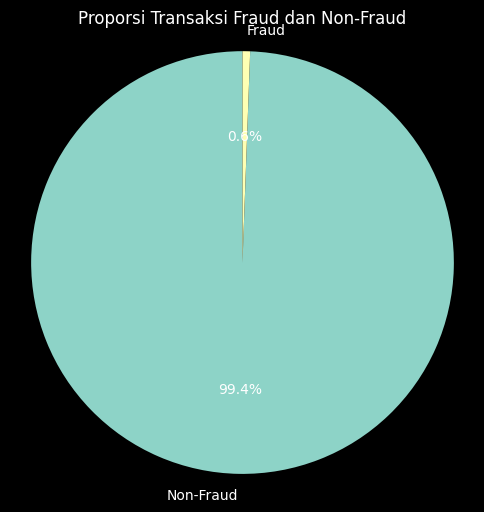

In [30]:
# Menghitung jumlah transaksi fraud dan non-fraud
fraud_counts = train['is_fraud'].value_counts()

# Membuat pie chart
plt.figure(figsize=(6, 6))
plt.pie(fraud_counts, labels=['Non-Fraud', 'Fraud'], autopct='%1.1f%%', startangle=90)
plt.title('Proporsi Transaksi Fraud dan Non-Fraud')
plt.axis('equal')  # Membuat pie chart berbentuk lingkaran
plt.show()

Artinya data ini dalah data Imbalance

## ETC EDA

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

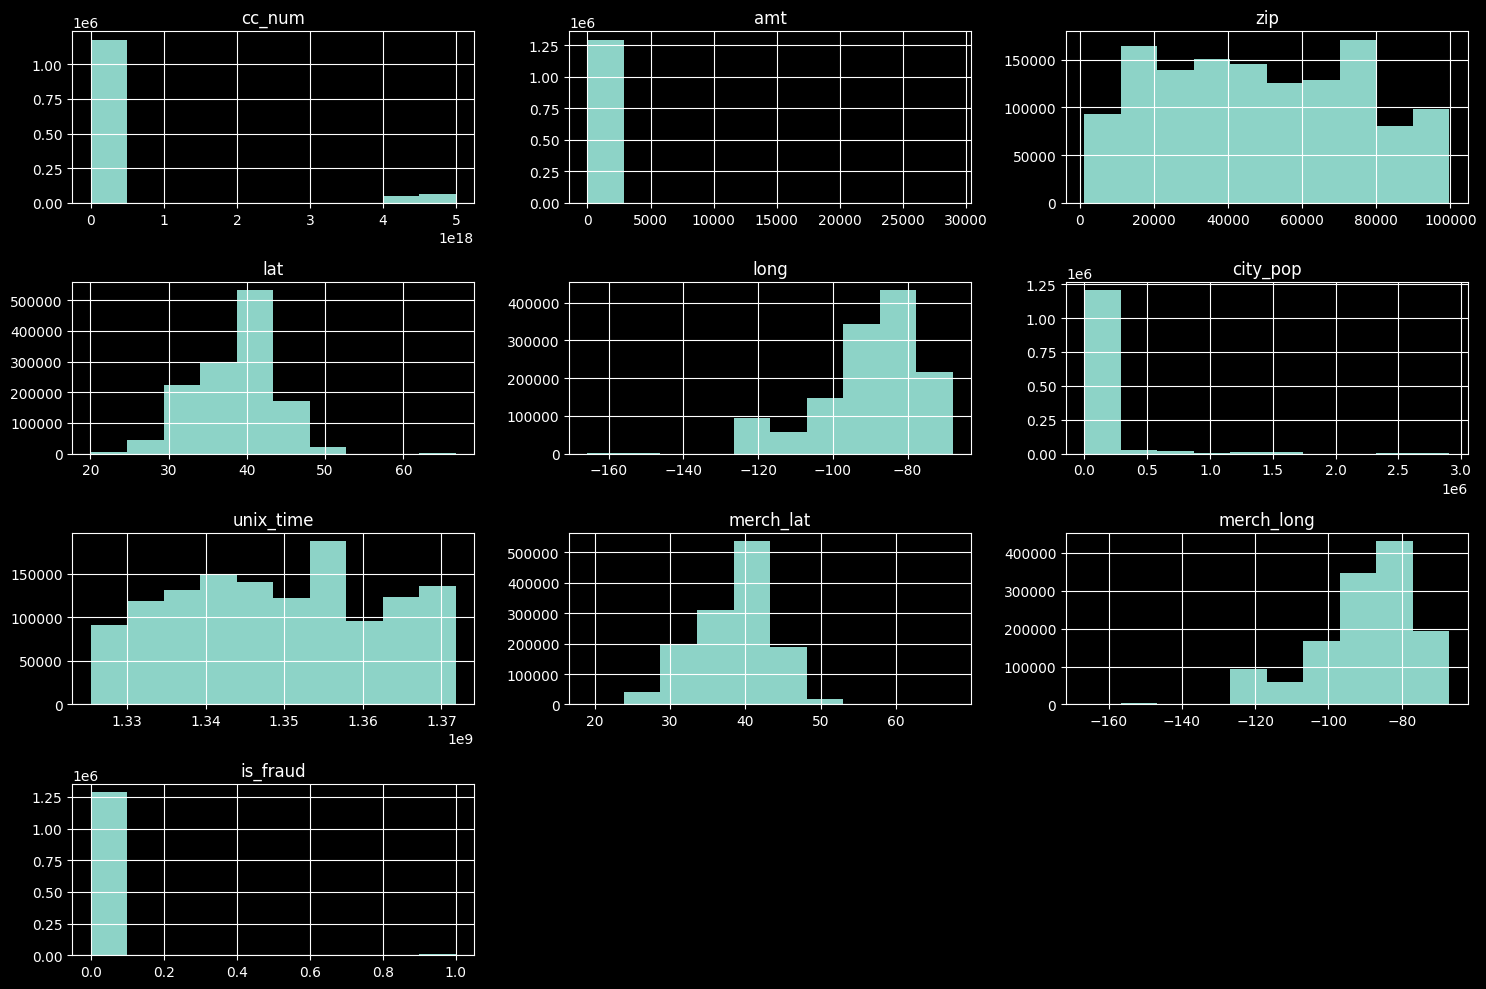

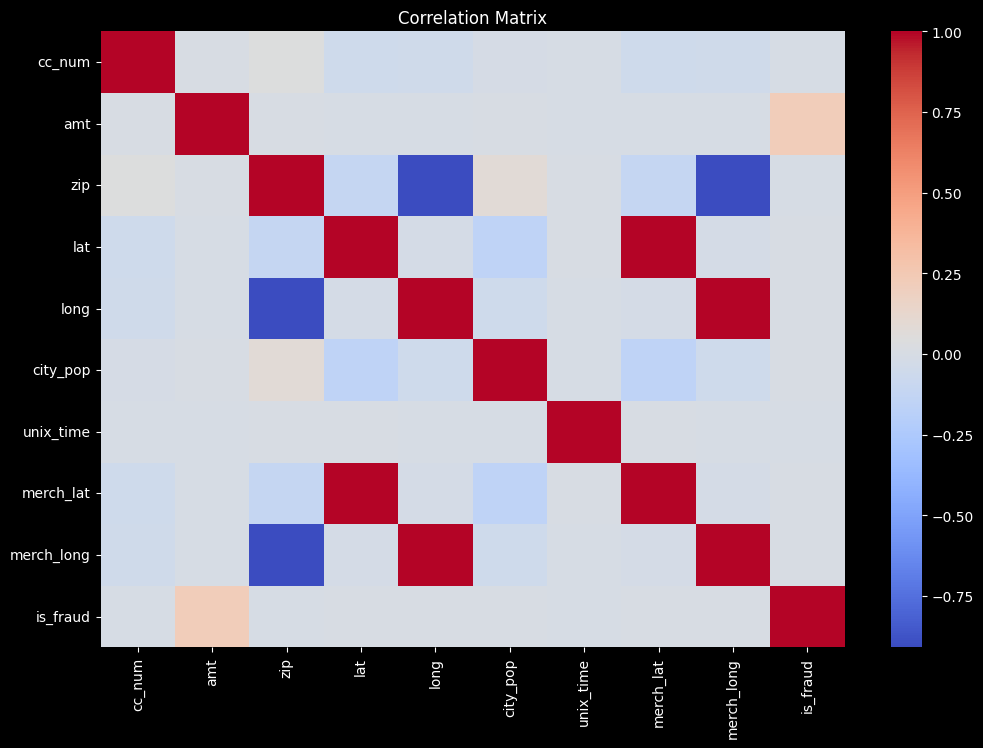

In [32]:
# Distribusi fitur numerik
train.hist(figsize=(15,10))
plt.tight_layout()
plt.show()

# Korelasi antar fitur
plt.figure(figsize=(12,8))
sns.heatmap(train.corr(numeric_only=True), annot=False, cmap='coolwarm') # Added numeric_only=True
plt.title("Correlation Matrix")
plt.show()

# Preprocessing Data

## Drop Identifier

In [33]:
# Drop kolom identity
train.drop(columns= indetifer,
              inplace=True)
train.head()

,trans_date_trans_time,merchant,category,amt,gender,street,city,state,zip,lat,long,city_pop,job,dob,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,"fraud_Rippin, Kub and Mann",misc_net,4.97,F,561 Perry Cove,Moravian Falls,NC,28654,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,1325376018,36.011293,-82.048315,0
1,2019-01-01 00:00:44,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1325376044,49.159047,-118.186462,0
2,2019-01-01 00:00:51,fraud_Lind-Buckridge,entertainment,220.11,M,594 White Dale Suite 530,Malad City,ID,83252,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,1325376051,43.150704,-112.154481,0
3,2019-01-01 00:01:16,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.2306,-112.1138,1939,Patent attorney,1967-01-12,1325376076,47.034331,-112.561071,0
4,2019-01-01 00:03:06,fraud_Keeling-Crist,misc_pos,41.96,M,408 Bradley Rest,Doe Hill,VA,24433,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,1325376186,38.674999,-78.632459,0


## Checking Data Duplicates (Optional)

In [34]:
# cek data duplicated
train.duplicated().sum()

np.int64(0)

## Checking Missing Value (Optional)

In [35]:
# Cek Missing value
train.isnull().sum()

,0
trans_date_trans_time,0
merchant,0
category,0
amt,0
gender,0
street,0
city,0
state,0
zip,0
lat,0


## Data Imputation (Optional)

In [36]:
# Imputasi sederhana (numerik = median, kategori = modus)
for col in train.columns:
    if train[col].dtype in ['int64', 'float64']:
        train[col].fillna(train[col].median(), inplace=True)
    else:
        train[col].fillna(train[col].mode()[0], inplace=True)

# Cek ulang
train.isnull().sum()

/tmp/ipykernel_21487/609744267.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train[col].fillna(train[col].mode()[0], inplace=True)
/tmp/ipykernel_21487/609744267.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)',

,0
trans_date_trans_time,0
merchant,0
category,0
amt,0
gender,0
street,0
city,0
state,0
zip,0
lat,0


## Feature Engineering / New Feature + Label Encoder Manually

### Time Category

In [37]:
import matplotlib
import matplotlib.pyplot as plt

In [38]:
# mengubah datetime
train['trans_date_trans_time'] = pd.to_datetime(train['trans_date_trans_time'])
train['dob'] = pd.to_datetime(train['dob'])

# Membuat date dan time transaksi
train['trans_date'] = train['trans_date_trans_time'].dt.date
train['trans_time'] = train['trans_date_trans_time'].dt.time

# membuat tahun, bulan, hari tahun transaksi
train['year'] = train['trans_date_trans_time'].dt.year
train['month'] = train['trans_date_trans_time'].dt.month
train['day'] = train['trans_date_trans_time'].dt.day
train['day_of_week'] = train['trans_date_trans_time'].dt.weekday
train['hour'] = train['trans_date_trans_time'].dt.hour

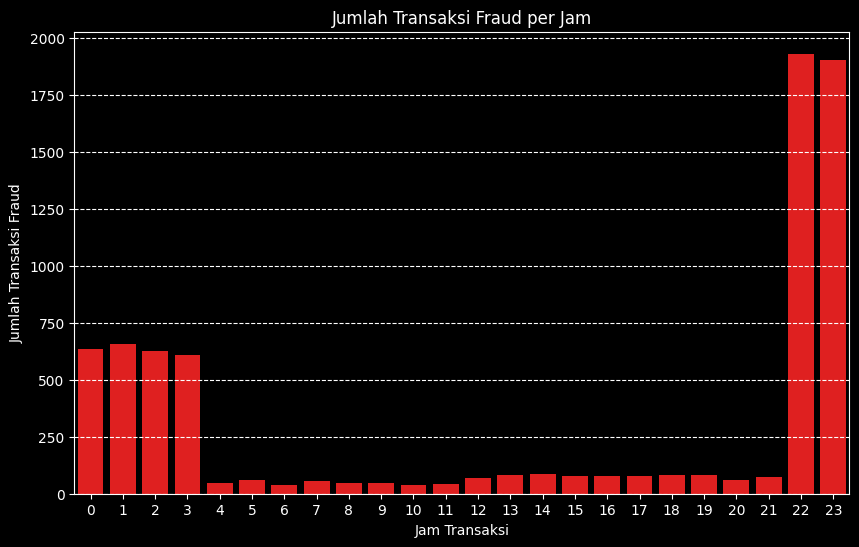

In [39]:
# Filter data yang merupakan transaksi fraud
fraud_data = train[train['is_fraud'] == 1].copy()

# Ekstrak jam dari kolom 'trans_date_trans_time' untuk data fraud
fraud_data['trans_hour'] = fraud_data['trans_date_trans_time'].dt.hour

# Hitung jumlah transaksi fraud per jam
fraud_by_hour = fraud_data['trans_hour'].value_counts().sort_index()

# Buat grafik batang (bar plot) jumlah transaksi fraud per jam
plt.figure(figsize=(10, 6))
sns.barplot(x=fraud_by_hour.index, y=fraud_by_hour.values, color='red')
plt.title('Jumlah Transaksi Fraud per Jam')
plt.xlabel('Jam Transaksi')
plt.ylabel('Jumlah Transaksi Fraud')
plt.xticks(np.arange(0, 24, 1)) # Menetapkan tick pada sumbu x untuk setiap jam
plt.grid(axis='y', linestyle='--')
plt.show()


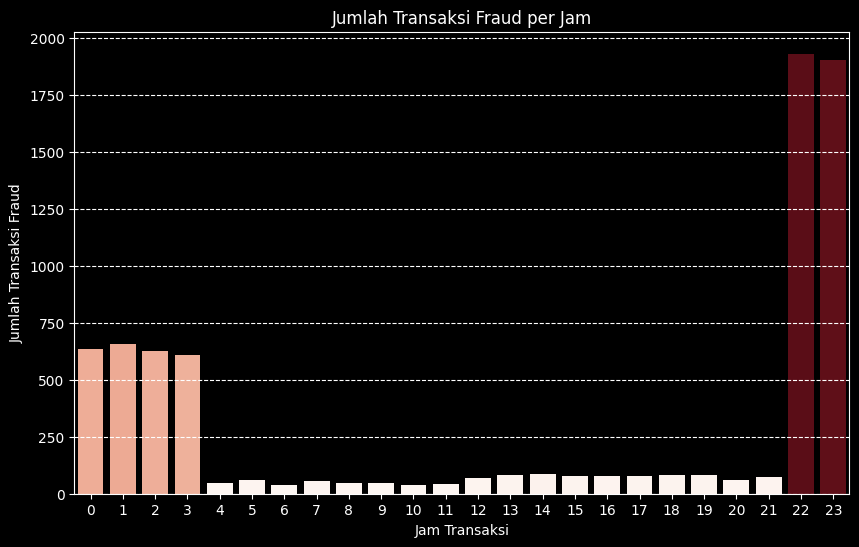

In [40]:
# Filter data yang merupakan transaksi fraud
fraud_data = train[train['is_fraud'] == 1].copy()

# Ekstrak jam dari kolom 'trans_date_trans_time' untuk data fraud
fraud_data['trans_hour'] = fraud_data['trans_date_trans_time'].dt.hour

# Hitung jumlah transaksi fraud per jam
fraud_by_hour = fraud_data['trans_hour'].value_counts().sort_index()

# Normalisasi jumlah transaksi fraud (0 - 1) untuk mapping warna
norm = (fraud_by_hour - fraud_by_hour.min()) / (fraud_by_hour.max() - fraud_by_hour.min())

# Gunakan API baru matplotlib colormaps
cmap = plt.colormaps.get_cmap('Reds')
colors = [cmap(n) for n in norm]

# Konversi data ke dataframe untuk memanfaatkan hue
fraud_df = fraud_by_hour.reset_index()
fraud_df.columns = ['trans_hour', 'fraud_count']

# Buat grafik batang (bar plot) dengan gradasi warna
plt.figure(figsize=(10, 6))
sns.barplot(data=fraud_df, x='trans_hour', y='fraud_count', hue='trans_hour', palette=colors, legend=False)
plt.title('Jumlah Transaksi Fraud per Jam')
plt.xlabel('Jam Transaksi')
plt.ylabel('Jumlah Transaksi Fraud')
plt.xticks(np.arange(0, 24, 1))  # Menetapkan tick pada sumbu x untuk setiap jam
plt.grid(axis='y', linestyle='--')
plt.show()

In [41]:
def categorize_risk_of_hour(hour):
  if hour >= 0 and hour <= 3:
    return  2 #'Risk Time'
  elif hour >= 4 and hour <= 21:
    return 1 #'Safe Time'
  elif hour >= 22 and hour <= 23:
    return 2 #'Risk Time'
  else:
    return 0 # 'Unknown'

train['risk_category_of_hour'] = train['hour'] .apply(categorize_risk_of_hour)
train.head()

,trans_date_trans_time,merchant,category,amt,gender,street,city,state,zip,lat,long,city_pop,job,dob,unix_time,merch_lat,merch_long,is_fraud,trans_date,trans_time,year,month,day,day_of_week,hour,risk_category_of_hour
0,2019-01-01 00:00:18,"fraud_Rippin, Kub and Mann",misc_net,4.97,F,561 Perry Cove,Moravian Falls,NC,28654,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,1325376018,36.011293,-82.048315,0,2019-01-01,00:00:18,2019,1,1,1,0,2
1,2019-01-01 00:00:44,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1325376044,49.159047,-118.186462,0,2019-01-01,00:00:44,2019,1,1,1,0,2
2,2019-01-01 00:00:51,fraud_Lind-Buckridge,entertainment,220.11,M,594 White Dale Suite 530,Malad City,ID,83252,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,1325376051,43.150704,-112.154481,0,2019-01-01,00:00:51,2019,1,1,1,0,2
3,2019-01-01 00:01:16,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.2306,-112.1138,1939,Patent attorney,1967-01-12,1325376076,47.034331,-112.561071,0,2019-01-01,00:01:16,2019,1,1,1,0,2
4,2019-01-01 00:03:06,fraud_Keeling-Crist,misc_pos,41.96,M,408 Bradley Rest,Doe Hill,VA,24433,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,1325376186,38.674999,-78.632459,0,2019-01-01,00:03:06,2019,1,1,1,0,2


### Distance

In [42]:
# Fungsi untuk menghitung jarak menggunakan rumus Haversine
def haversine(lat1, lon1, lat2, lon2):
    # Konversi dari derajat ke radian
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

    # Haversine formula
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))

    # Jarak dalam kilometer (radius bumi = 6371 km)
    distance = 6371 * c
    return distance

In [43]:
# Menghitung jarak untuk setiap transaksi
train['distance'] = train.apply(lambda row: haversine(row['lat'], row['long'], row['merch_lat'], row['merch_long']), axis=1)

In [44]:
# Misalkan df adalah DataFrame yang berisi kolom 'distance'
bins = [0, train['distance'].quantile(0.25), train['distance'].quantile(0.75), train['distance'].max()]
#labels = ['Dekat', 'Sedang', 'Jauh']

labels = [1,2,3]

# Membuat kolom baru 'distance_category'
train['distance_category'] = pd.cut(train['distance'], bins=bins, labels=labels, include_lowest=True)
train.head()

,trans_date_trans_time,merchant,category,amt,gender,street,city,state,zip,lat,long,city_pop,job,dob,unix_time,merch_lat,merch_long,is_fraud,trans_date,trans_time,year,month,day,day_of_week,hour,risk_category_of_hour,distance,distance_category
0,2019-01-01 00:00:18,"fraud_Rippin, Kub and Mann",misc_net,4.97,F,561 Perry Cove,Moravian Falls,NC,28654,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,1325376018,36.011293,-82.048315,0,2019-01-01,00:00:18,2019,1,1,1,0,2,78.597568,2
1,2019-01-01 00:00:44,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1325376044,49.159047,-118.186462,0,2019-01-01,00:00:44,2019,1,1,1,0,2,30.212176,1
2,2019-01-01 00:00:51,fraud_Lind-Buckridge,entertainment,220.11,M,594 White Dale Suite 530,Malad City,ID,83252,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,1325376051,43.150704,-112.154481,0,2019-01-01,00:00:51,2019,1,1,1,0,2,108.206083,3
3,2019-01-01 00:01:16,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.2306,-112.1138,1939,Patent attorney,1967-01-12,1325376076,47.034331,-112.561071,0,2019-01-01,00:01:16,2019,1,1,1,0,2,95.673231,2
4,2019-01-01 00:03:06,fraud_Keeling-Crist,misc_pos,41.96,M,408 Bradley Rest,Doe Hill,VA,24433,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,1325376186,38.674999,-78.632459,0,2019-01-01,00:03:06,2019,1,1,1,0,2,77.556744,2


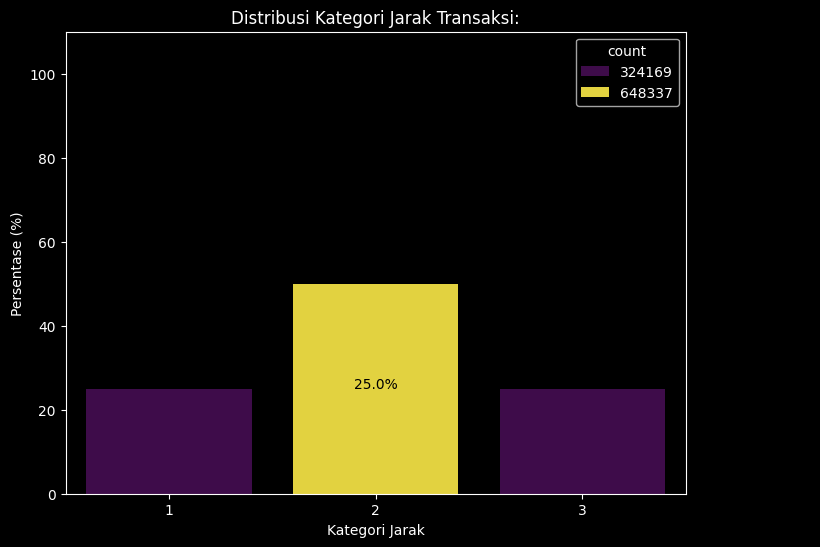

In [45]:
# Hitung frekuensi dan persentase untuk setiap kategori jarak
distance_counts = train['distance_category'].value_counts()
distance_percentages = train['distance_category'].value_counts(normalize=True) * 100

# Gabungkan keduanya ke dalam satu DataFrame
distance_summary = pd.DataFrame({
    'Count': distance_counts,
    'Percentage': distance_percentages
})

# Buat visualisasi
plt.figure(figsize=(8, 6))
sns.barplot(x=distance_summary.index, y=distance_summary['Percentage'], palette='viridis', hue=distance_counts)
plt.title('Distribusi Kategori Jarak Transaksi:')
plt.xlabel('Kategori Jarak')
plt.ylabel('Persentase (%)')

# Menampilkan persentase di atas setiap bar
for index, row in distance_summary.iterrows():
    plt.text(index, row['Percentage'], f'{row["Percentage"]:.1f}%', color='black', ha="center")

plt.ylim(0, 110) # Sesuaikan batas y agar persentase terlihat jelas
plt.show()

### Age

In [47]:
# age = trans_date - dob

# Pastikan format datetime
train['trans_date'] = pd.to_datetime(train['trans_date'])
train['dob'] = pd.to_datetime(train['dob'])

# Hitung umur (dalam tahun)
train['age'] = (train['trans_date'] - train['dob']).dt.days // 365

# Cek hasil
train[['dob', 'trans_date', 'age']].head()

,dob,trans_date,age
0,1988-03-09,2019-01-01,30
1,1978-06-21,2019-01-01,40
2,1962-01-19,2019-01-01,56
3,1967-01-12,2019-01-01,52
4,1986-03-28,2019-01-01,32


### Risk on Category Variable

Tujuannya: lihat kategori mana yang paling sering fraud

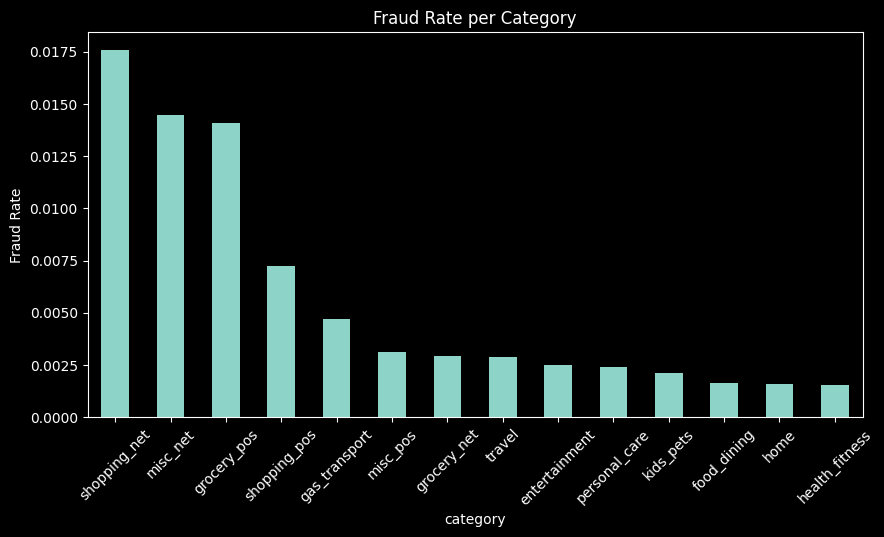

In [51]:
 # viz for category, is_fraud = 1

 # Proporsi fraud per kategori
fraud_rate = train.groupby('category')['is_fraud'].mean().sort_values(ascending=False)

# Plot
plt.figure(figsize=(10,5))
fraud_rate.plot(kind='bar')
plt.title("Fraud Rate per Category")
plt.ylabel("Fraud Rate")
plt.xticks(rotation=45)
plt.show()

In [61]:
df_cat = train.groupby('category')['is_fraud'].mean().reset_index()
df_cat.columns = ['category', 'fraud_rate']

# Urutkan kategori berdasarkan fraud_rate secara ascending
df_cat_sorted = df_cat.sort_values(by='fraud_rate', ascending=True)

# Buat mapping untuk encoding
# Rank 1 untuk fraud_rate terendah, rank 14 untuk fraud_rate tertinggi
category_fraud_rank_mapping = {category: rank + 1 for rank, category in enumerate(df_cat_sorted['category'])}

# Buat kolom baru 'category_basedon_fraud' di DataFrame train
train['category_basedon_fraud'] = train['category'].map(category_fraud_rank_mapping)

# Tampilkan beberapa baris pertama dengan kolom baru
print(train[['category', 'category_basedon_fraud', 'is_fraud']])

              category  category_basedon_fraud  is_fraud
0             misc_net                      13         0
1          grocery_pos                      12         0
2        entertainment                       6         0
3        gas_transport                      10         0
4             misc_pos                       9         0
...                ...                     ...       ...
1296670  entertainment                       6         0
1296671    food_dining                       3         0
1296672    food_dining                       3         0
1296673    food_dining                       3         0
1296674    food_dining                       3         0

[1296675 rows x 3 columns]


In [69]:
# Jumlah transaksi vs fraud
cat_count = train['category'].value_counts()
cat_fraud = train[train['is_fraud']==1]['category'].value_counts()

df_cat = pd.DataFrame({
    'total': cat_count,
    'fraud': cat_fraud
}).fillna(0)

df_cat['fraud_rate'] = df_cat['fraud'] / df_cat['total']
df_cat.sort_values('fraud_rate', ascending=False).head()

,total,fraud,fraud_rate
category,,,
shopping_net,97543,1713,0.017561
misc_net,63287,915,0.014458
grocery_pos,123638,1743,0.014098
shopping_pos,116672,843,0.007225
gas_transport,131659,618,0.004694


### ETC

In [70]:
# Cek missing value
missing = train.isnull().sum().sort_values(ascending=False)
print(missing[missing > 0])

Series([], dtype: int64)


In [71]:
# Cek duplikasi
print("Duplicate rows:", train.duplicated().sum())

Duplicate rows: 0


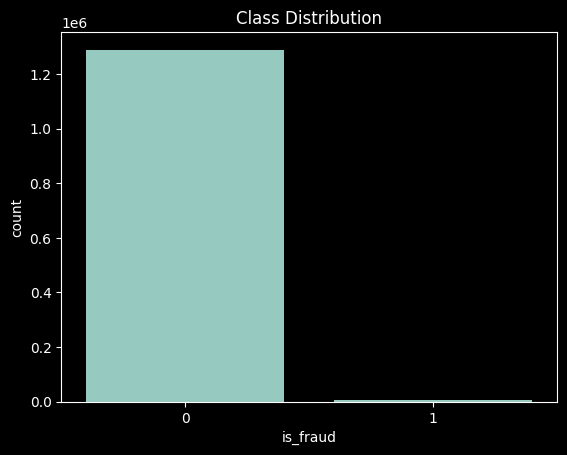

In [72]:
# Distribusi target
sns.countplot(x='is_fraud', data=train)
plt.title("Class Distribution")
plt.show()

#FEATURE SELECTION

In [73]:
train.columns

Index(['trans_date_trans_time', 'merchant', 'category', 'amt', 'gender',
       'street', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job',
       'dob', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud', 'trans_date',
       'trans_time', 'year', 'month', 'day', 'day_of_week', 'hour',
       'risk_category_of_hour', 'distance', 'distance_category', 'age',
       'category_basedon_fraud'],
      dtype='object')

In [74]:
train.head(3)

,trans_date_trans_time,merchant,category,amt,gender,street,city,state,zip,lat,long,city_pop,job,dob,unix_time,merch_lat,merch_long,is_fraud,trans_date,trans_time,year,month,day,day_of_week,hour,risk_category_of_hour,distance,distance_category,age,category_basedon_fraud
0,2019-01-01 00:00:18,"fraud_Rippin, Kub and Mann",misc_net,4.97,F,561 Perry Cove,Moravian Falls,NC,28654,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,1325376018,36.011293,-82.048315,0,2019-01-01,00:00:18,2019,1,1,1,0,2,78.597568,2,30,13
1,2019-01-01 00:00:44,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1325376044,49.159047,-118.186462,0,2019-01-01,00:00:44,2019,1,1,1,0,2,30.212176,1,40,12
2,2019-01-01 00:00:51,fraud_Lind-Buckridge,entertainment,220.11,M,594 White Dale Suite 530,Malad City,ID,83252,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,1325376051,43.150704,-112.154481,0,2019-01-01,00:00:51,2019,1,1,1,0,2,108.206083,3,56,6


In [82]:
unless_columns = ['trans_date_trans_time','merchant','category','gender','street', 'city', 'state', 'zip', 'lat', 'long','job','trans_time','year','hour','distance','dob', 'unix_time', 'merch_lat', 'merch_long','trans_date','trans_time']

# Train Test Split

In [98]:
from sklearn.model_selection import train_test_split

X = train.drop('is_fraud', axis=1)
# Drop non-numerical and redundant datetime columns from X
X = X.drop(columns=unless_columns, errors='ignore')
y = train['is_fraud']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (1037340, 9)
Shape of X_test: (259335, 9)
Shape of y_train: (1037340,)
Shape of y_test: (259335,)


In [99]:
y_train.value_counts()

,count
is_fraud,
0,1031335
1,6005


## Original Data

In [100]:
y_train.value_counts()

,count
is_fraud,
0,1031335
1,6005


## Handling Imbalance Data (Training Data) (Optional)

Hanya data train aja yang boleh di Handling Imbalance

In [101]:
!pip install -q imbalanced-learn

### SMOTE

In [102]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Shape of X_train after SMOTE:", X_train_smote.shape)
print("Shape of y_train after SMOTE:", y_train_smote.shape)
print("\nValue counts of y_train before SMOTE:")
print(y_train.value_counts())
print("\nValue counts of y_train after SMOTE:")
print(y_train_smote.value_counts())

Shape of X_train after SMOTE: (2062670, 9)
Shape of y_train after SMOTE: (2062670,)

Value counts of y_train before SMOTE:
is_fraud
0    1031335
1       6005
Name: count, dtype: int64

Value counts of y_train after SMOTE:
is_fraud
0    1031335
1    1031335
Name: count, dtype: int64


# Modelling

## Logistics Regression

In [103]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

lr = LogisticRegression(random_state=123)
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00    257834
           1       0.01      0.00      0.00      1501

    accuracy                           0.99    259335
   macro avg       0.50      0.50      0.50    259335
weighted avg       0.99      0.99      0.99    259335



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


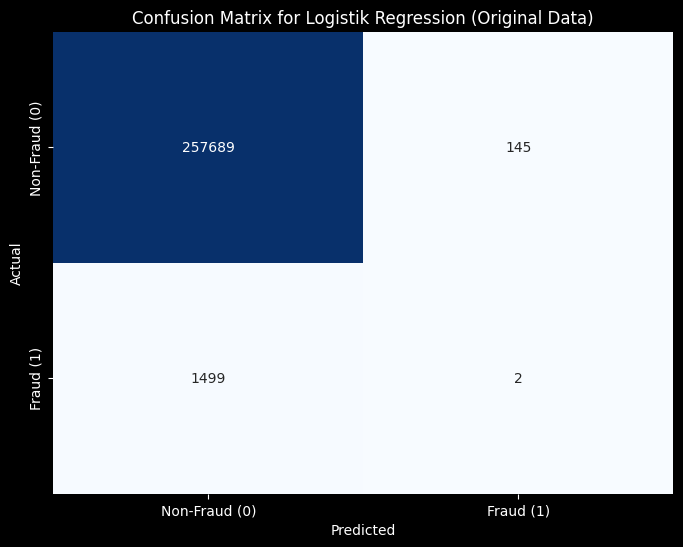

In [104]:
# Visualisasi Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Non-Fraud (0)', 'Fraud (1)'], yticklabels=['Non-Fraud (0)', 'Fraud (1)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Logistik Regression (Original Data)')
plt.show()

In [105]:
from sklearn.metrics import classification_report

# Get the classification report as a dictionary
report_dict = classification_report(y_test, y_pred, output_dict=True)

# Extract macro average F1 score
macro_avg_f1_lr = report_dict['macro avg']['f1-score']

print(f"Macro Average F1 Score (Logistic Regression): {macro_avg_f1_lr:.2f}")

Macro Average F1 Score (Logistic Regression): 0.50


### Hyperparameter Tuning (Optional)

In [97]:
# from sklearn.model_selection import GridSearchCV

# param_grid = {
#     'C': [0.01, 0.1, 1, 10],
#     'solver': ['liblinear', 'lbfgs']
# }

# grid = GridSearchCV(LogisticRegression(max_iter=1000), param_grid, cv=3, scoring='f1')
# grid.fit(X_train_smote, y_train_smote)

# print("Best Params:", grid.best_params_)

## RandomForest

In [106]:
from sklearn.ensemble import RandomForestClassifier

# Inisialisasi model RandomForestClassifier
rf_model = RandomForestClassifier(random_state=123)

# Latih model menggunakan data training asli
rf_model.fit(X_train, y_train)

print("RandomForestClassifier model trained successfully on original data.")

RandomForestClassifier model trained successfully on original data.


Classification Report for RandomForest (Original Data):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    257834
           1       0.90      0.72      0.80      1501

    accuracy                           1.00    259335
   macro avg       0.95      0.86      0.90    259335
weighted avg       1.00      1.00      1.00    259335



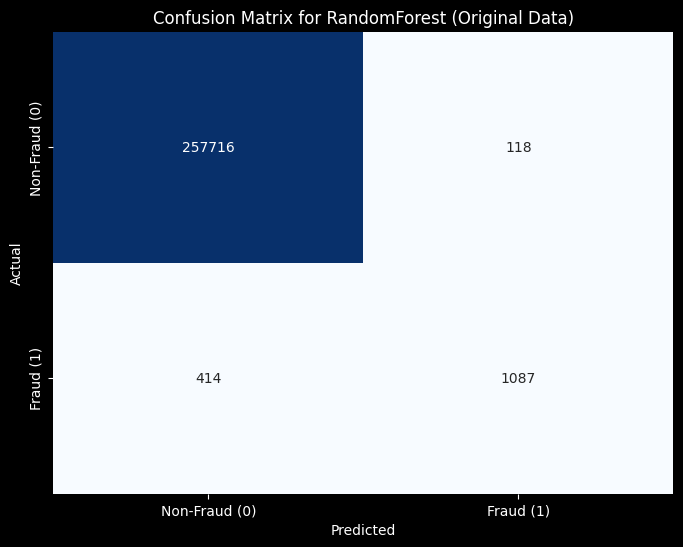

In [107]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Prediksi pada data test asli
y_pred_rf = rf_model.predict(X_test)

# Evaluasi model
print("Classification Report for RandomForest (Original Data):")
print(classification_report(y_test, y_pred_rf))

# Visualisasi Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Non-Fraud (0)', 'Fraud (1)'], yticklabels=['Non-Fraud (0)', 'Fraud (1)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for RandomForest (Original Data)')
plt.show()

In [108]:
# Get the classification report as a dictionary
report_dict = classification_report(y_test, y_pred_rf, output_dict=True)

# Extract macro average F1 score
macro_avg_f1_rf = report_dict['macro avg']['f1-score']

print(f"Macro Average F1 Score (Random Forest): {macro_avg_f1_rf:.2f}")

Macro Average F1 Score (Random Forest): 0.90


In [109]:
# example : Macro Avg F1

### Hyperparameter Tuning (Optional)

## Others Model (Optional)

###AdaBoost

In [110]:
from sklearn.ensemble import AdaBoostClassifier

# Inisialisasi model RandomForestClassifier
adaB_model = AdaBoostClassifier(random_state=123)

# Latih model menggunakan data training asli
adaB_model.fit(X_train, y_train)

print("AdaBoostClassifier model trained successfully on original data.")

AdaBoostClassifier model trained successfully on original data.


Classification Report for AdaBoost (Original Data):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    257834
           1       0.75      0.36      0.49      1501

    accuracy                           1.00    259335
   macro avg       0.88      0.68      0.74    259335
weighted avg       0.99      1.00      0.99    259335



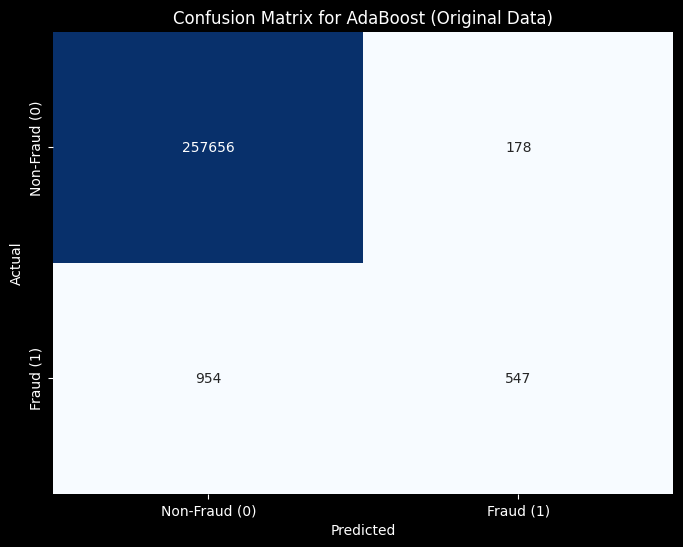

In [111]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Prediksi pada data test asli
y_pred_adaB = adaB_model.predict(X_test)

# Evaluasi model
print("Classification Report for AdaBoost (Original Data):")
print(classification_report(y_test, y_pred_adaB))

# Visualisasi Confusion Matrix
cm_adaB = confusion_matrix(y_test, y_pred_adaB)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_adaB, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Non-Fraud (0)', 'Fraud (1)'], yticklabels=['Non-Fraud (0)', 'Fraud (1)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for AdaBoost (Original Data)')
plt.show()

In [112]:
# Get the classification report as a dictionary
report_dict = classification_report(y_test, y_pred_adaB, output_dict=True)

# Extract macro average F1 score
macro_avg_f1_adaB = report_dict['macro avg']['f1-score']

print(f"Macro Average F1 Score (AdaBoost): {macro_avg_f1_adaB:.2f}")

Macro Average F1 Score (AdaBoost): 0.74


# Model Comparison

In [113]:
# Metrics Table

import pandas as pd

comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest','AdaBoost'],
    'Macro avg F1-score': [macro_avg_f1_lr, macro_avg_f1_rf, macro_avg_f1_adaB],

})

comparison.set_index('Model', inplace=True)
comparison

,Macro avg F1-score
Model,
Logistic Regression,0.499624
Random Forest,0.901184
AdaBoost,0.744636


# Features Importance

                  Feature  Importance
0                     amt    0.494551
8  category_basedon_fraud    0.193969
1                city_pop    0.078246
7                     age    0.061671
5   risk_category_of_hour    0.052002
3                     day    0.047091
2                   month    0.031283
4             day_of_week    0.026218
6       distance_category    0.014969


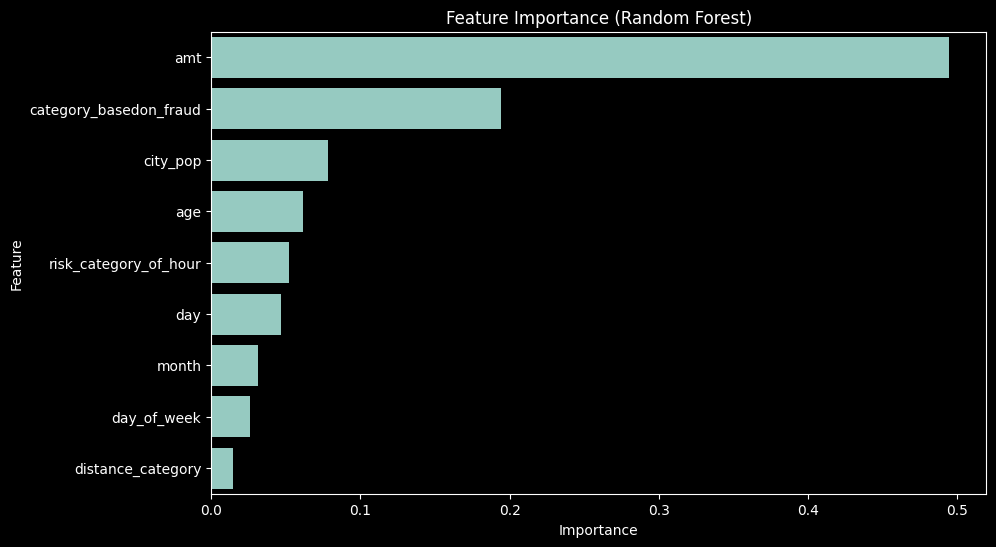

In [114]:
feature_importance_rf = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(feature_importance_rf)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_rf)
plt.title("Feature Importance (Random Forest)")
plt.show()